# 5D LQG Model with u and x̂ perturbations

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from model import lqg_model

%matplotlib inline

## Initialize 5D LQG Model with Parameters

In [2]:
n_dim = 5
state_dim = 2 * n_dim   # 10: [p1, v1, p2, v2, p3, v3, p4, v4, p5, v5]
ctrl_dim  = n_dim        # 5:  [a1, a2, a3, a4, a5]

horizon = 1000 # time steps
dt = 0.01  # time step in seconds (10 ms per step), 10 sec total w 1000 steps

# targets: all positions = 100, all velocities = 0
T_pos = [100] * n_dim
T_vel = [0]   * n_dim
target_vec = []
for i in range(n_dim):
    target_vec.extend([T_pos[i], T_vel[i]])

# instantiate LQG model
lqg_baseline = lqg_model.LQG(horizon, target=target_vec)
target = np.matrix(target_vec).reshape(-1, 1)

# initial state: all zeros
x0 = np.matrix(np.zeros((state_dim, 1)))

# A: state transition matrix (block diagonal: decoupled dimensions)
A_arr = np.zeros((state_dim, state_dim))
for i in range(n_dim):
    A_arr[2*i,   2*i]   = 1
    A_arr[2*i,   2*i+1] = dt
    A_arr[2*i+1, 2*i+1] = 1
A = np.matrix(A_arr)

# B: control input matrix (each acceleration drives its dimension's velocity)
B_arr = np.zeros((state_dim, ctrl_dim))
for i in range(n_dim):
    B_arr[2*i+1, i] = dt
B = np.matrix(B_arr)

# C: observation matrix (observe all states)
C = np.matrix(np.eye(state_dim))

# Q: state cost — high penalty on position error, low on velocity
q_diag = []
for i in range(n_dim):
    q_diag.extend([500, 1])
Q = np.matrix(np.diag(q_diag))

# R: control cost
R = np.matrix(0.0001 * np.eye(ctrl_dim))

# V: process noise covariance
V = np.matrix(0.001 * np.eye(state_dim))

# W: measurement noise covariance
W = np.matrix(1.5 * np.eye(state_dim))

# X0: initial state covariance
X0_mat = np.matrix(0.1 * np.eye(state_dim))

lqg_baseline.define('A', A)
lqg_baseline.define('B', B)
lqg_baseline.define('C', C)
lqg_baseline.define('Q', Q)
lqg_baseline.define('R', R)
lqg_baseline.define('V', V)
lqg_baseline.define('W', W)
lqg_baseline.define('X', X0_mat)

state_labels = []
for i in range(n_dim):
    state_labels.extend([f'p{i+1}', f'v{i+1}'])
ctrl_labels = [f'a{i+1}' for i in range(n_dim)]

print(f"{n_dim}D LQG model:")
print(f"\tHorizon: {horizon} time steps, dt={dt}s")
print(f"\tState ({state_dim}D): {state_labels}")
print(f"\tControl ({ctrl_dim}D): {ctrl_labels}")
print(f"\tTarget: {', '.join([f'p{i+1}={T_pos[i]}' for i in range(n_dim)])}")

5D LQG model:
	Horizon: 1000 time steps, dt=0.01s
	State (10D): ['p1', 'v1', 'p2', 'v2', 'p3', 'v3', 'p4', 'v4', 'p5', 'v5']
	Control (5D): ['a1', 'a2', 'a3', 'a4', 'a5']
	Target: p1=100, p2=100, p3=100, p4=100, p5=100


## Baseline Simulation (No Perturbation)

In [3]:
np.random.seed(42)

v_noise = [np.random.randn(state_dim, 1) for _ in range(horizon)]
w_noise = [np.random.randn(state_dim, 1) for _ in range(horizon)]

x_baseline_list    = [x0.copy()]
xhat_baseline_list = [x0.copy()]
u_baseline_list    = []

lqg_baseline.kalman()
lqg_baseline.control()

for t in range(horizon - 1):
    u_t = lqg_baseline.var['K'][t] * (xhat_baseline_list[t] - target)
    u_baseline_list.append(u_t)

    x_next = A * x_baseline_list[t] + B * u_t + V * np.matrix(v_noise[t])
    x_baseline_list.append(x_next)

    y = C * x_next + W * np.matrix(w_noise[t + 1])

    xhat_pred = A * xhat_baseline_list[t] + B * u_t
    y_tilde   = y - C * xhat_pred
    xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde
    xhat_baseline_list.append(xhat_next)

u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_baseline_list[-1] - target)
u_baseline_list.append(u_final)

# extract positions from state vector (at even indices: 0, 2, 4, 6, 8)
pos_baseline    = {f'p{i+1}': np.array([x_baseline_list[t][2*i, 0]    for t in range(horizon)]) for i in range(n_dim)}
poshat_baseline = {f'p{i+1}': np.array([xhat_baseline_list[t][2*i, 0] for t in range(horizon)]) for i in range(n_dim)}

baseline_data = {
    'x':   x_baseline_list,
    'kf':  {'x1': xhat_baseline_list},
    'u':   u_baseline_list,
    'noise': {
        'v': [np.matrix(v_noise[t]) for t in range(horizon)],
        'w': [np.matrix(w_noise[t]) for t in range(horizon)]
    },
    'target': target
}

print("baseline simulation summary:")
for i in range(n_dim):
    k = f'p{i+1}'
    print(f"\t{k} final: {pos_baseline[k][-1]:.4f}  (target {T_pos[i]})")
    print(f"\tmean |{k} - {k}hat|: {np.mean(np.abs(pos_baseline[k] - poshat_baseline[k])):.4f}")

baseline simulation summary:
	p1 final: 99.8803  (target 100)
	mean |p1 - p1hat|: 0.0445
	p2 final: 100.0050  (target 100)
	mean |p2 - p2hat|: 0.0905
	p3 final: 99.9529  (target 100)
	mean |p3 - p3hat|: 0.0499
	p4 final: 99.9079  (target 100)
	mean |p4 - p4hat|: 0.1182
	p5 final: 99.9839  (target 100)
	mean |p5 - p5hat|: 0.0438


## Perturb u (all axes)
- inject a pulse (decrease in acceleration) into u for all 5 axes simultaneously
- Kalman uses u_actual as efference copy, so x and xhat stay aligned in all axes

In [4]:
np.random.seed(42)

perturbation_start     = 200
perturbation_end       = 250

# per-dimension control perturbation magnitudes (one per acceleration axis)
# set individually to isolate or vary perturbation strength across axes
u_pert_magnitudes = [-87, -112, -63, -134, -79]   # [ax1, ax2, ax3, ax4, ax5]

v_noise = baseline_data['noise']['v']
w_noise = baseline_data['noise']['w']

x_u_pert_list    = [baseline_data['x'][t].copy()        for t in range(perturbation_start + 1)]
xhat_u_pert_list = [baseline_data['kf']['x1'][t].copy() for t in range(perturbation_start + 1)]
u_u_pert_list    = [baseline_data['u'][t].copy()        for t in range(perturbation_start)]

for t in range(perturbation_start, horizon - 1):
    u_intended = lqg_baseline.var['K'][t] * (xhat_u_pert_list[t] - target)
    u_actual   = u_intended.copy()
    if perturbation_start <= t < perturbation_end:
        for i in range(ctrl_dim):
            u_actual[i, 0] += u_pert_magnitudes[i]
    u_u_pert_list.append(u_actual)

    x_next = A * x_u_pert_list[t] + B * u_actual + V * v_noise[t]
    x_u_pert_list.append(x_next)

    y         = C * x_next + W * w_noise[t + 1]
    xhat_pred = A * xhat_u_pert_list[t] + B * u_actual  # efference copy
    y_tilde   = y - C * xhat_pred
    xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde
    xhat_u_pert_list.append(xhat_next)

u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_u_pert_list[-1] - target)
u_u_pert_list.append(u_final)

pos_u_pert    = {f'p{i+1}': np.array([x_u_pert_list[t][2*i, 0]    for t in range(horizon)]) for i in range(n_dim)}
poshat_u_pert = {f'p{i+1}': np.array([xhat_u_pert_list[t][2*i, 0] for t in range(horizon)]) for i in range(n_dim)}

u_pert_data = {
    'x':  x_u_pert_list,
    'kf': {'x1': xhat_u_pert_list},
    'u':  u_u_pert_list,
    'noise': baseline_data['noise'],
    'target': target
}

errors_u = {f'p{i+1}': pos_u_pert[f'p{i+1}'] - poshat_u_pert[f'p{i+1}'] for i in range(n_dim)}

print("Control (u) Perturbation — per-axis pulse:")
print(f"  perturbation: t={perturbation_start} to t={perturbation_end}, magnitudes: {u_pert_magnitudes}")
for i in range(n_dim):
    k = f'p{i+1}'
    e = errors_u[k]
    print(f"  mean |{k}-{k}hat| before/during/after: "
          f"{np.mean(np.abs(e[:perturbation_start])):.5f} / "
          f"{np.mean(np.abs(e[perturbation_start:perturbation_end])):.5f} / "
          f"{np.mean(np.abs(e[perturbation_end:])):.5f}")

Control (u) Perturbation — per-axis pulse:
  perturbation: t=200 to t=250, magnitudes: [-87, -112, -63, -134, -79]
  mean |p1-p1hat| before/during/after: 0.04523 / 0.03396 / 0.04506
  mean |p2-p2hat| before/during/after: 0.12508 / 0.24398 / 0.07099
  mean |p3-p3hat| before/during/after: 0.03702 / 0.08361 / 0.05107
  mean |p4-p4hat| before/during/after: 0.06477 / 0.02341 / 0.13876
  mean |p5-p5hat| before/during/after: 0.07009 / 0.10949 / 0.03245


## xhat perturbation (position bias in all axes)

- during the window, a position bias is applied to all xhat position components after each Kalman correction
- this models a persistent external bias on the full position estimate (e.g. a visual perturbation)
- the controller uses the biased xhat → applies wrong acceleration in all axes → x and xhat diverge
- when the window ends, the Kalman corrects xhat back toward x via its own dynamics

In [5]:
from scipy.optimize import brentq

xhat_pulse_duration = 50
_xhat_pulse_end = min(perturbation_start + xhat_pulse_duration, horizon)

# calibrate xhat perturbation magnitude to match target |p1 deviation| at perturbation_end
target_p1_dev_mag = abs(pos_u_pert['p1'][perturbation_end] - pos_baseline['p1'][perturbation_end])
print(f"Target |p1 deviation| at t={perturbation_end}: {target_p1_dev_mag:.4f}  (from u perturbation)")
print(f"  u perturbation p1 dev: {pos_u_pert['p1'][perturbation_end] - pos_baseline['p1'][perturbation_end]:.4f}")

def _simulate_xhat_pert(offset):
    """run xhat perturbation for a given per-step position bias in all axes; return (p1_arr, p1hat_arr)."""
    v_n = baseline_data['noise']['v']
    w_n = baseline_data['noise']['w']
    tgt = baseline_data['target']

    x_list    = [baseline_data['x'][t].copy()        for t in range(perturbation_start + 1)]
    xhat_list = [baseline_data['kf']['x1'][t].copy() for t in range(perturbation_start + 1)]
    u_list    = [baseline_data['u'][t].copy()        for t in range(perturbation_start)]

    for t in range(perturbation_start, horizon - 1):
        u_t = lqg_baseline.var['K'][t] * (xhat_list[t] - tgt)
        u_list.append(u_t)

        x_next    = A * x_list[t] + B * u_t + V * v_n[t]
        x_list.append(x_next)

        y         = C * x_next + W * w_n[t + 1]
        xhat_pred = A * xhat_list[t] + B * u_t
        y_tilde   = y - C * xhat_pred
        xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde

        if perturbation_start <= (t + 1) < _xhat_pulse_end:
            for i in range(n_dim):
                xhat_next[2*i, 0] += offset  # all position components biased

        xhat_list.append(xhat_next)

    u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_list[-1] - tgt)
    u_list.append(u_final)

    p1_arr    = np.array([x_list[t][0, 0]    for t in range(horizon)])
    p1hat_arr = np.array([xhat_list[t][0, 0] for t in range(horizon)])
    return p1_arr, p1hat_arr

def _deviation_diff(offset):
    p1_arr, _ = _simulate_xhat_pert(offset)
    dev_mag = abs(p1_arr[perturbation_end] - pos_baseline['p1'][perturbation_end])
    return dev_mag - target_p1_dev_mag

xhat_position_offset = brentq(_deviation_diff, -200.0, -0.001, xtol=1e-6)

_p1_cal, _p1hat_cal = _simulate_xhat_pert(xhat_position_offset)
_cal_p1_dev  = _p1_cal[perturbation_end]    - pos_baseline['p1'][perturbation_end]
_cal_p1h_dev = _p1hat_cal[perturbation_end] - poshat_baseline['p1'][perturbation_end]
_u_p1h_dev   = poshat_u_pert['p1'][perturbation_end] - poshat_baseline['p1'][perturbation_end]

print(f"\nCalibrated xhat_position_offset = {xhat_position_offset:.4f}  (negative: xhat pushed backward)")
print(f"  |p1 dev| at t={perturbation_end} (u pert):    {abs(pos_u_pert['p1'][perturbation_end] - pos_baseline['p1'][perturbation_end]):.4f}")
print(f"  |p1 dev| at t={perturbation_end} (xhat pert): {abs(_cal_p1_dev):.4f}")
print(f"  p1hat dev at t={perturbation_end} (u pert):    {_u_p1h_dev:.4f}")
print(f"  p1hat dev at t={perturbation_end} (xhat pert): {_cal_p1h_dev:.4f}  (same sign: both negative)")

Target |p1 deviation| at t=250: 9.8099  (from u perturbation)
  u perturbation p1 dev: -9.8099

Calibrated xhat_position_offset = -68.0794  (negative: xhat pushed backward)
  |p1 dev| at t=250 (u pert):    9.8099
  |p1 dev| at t=250 (xhat pert): 9.8099
  p1hat dev at t=250 (u pert):    -9.8099
  p1hat dev at t=250 (xhat pert): -2822.0742  (same sign: both negative)


In [6]:
np.random.seed(42)

# xhat_position_offset and xhat_pulse_duration come from the calibration cell above
# per-dimension xhat bias controls (one entry per spatial dimension):
#   pos_scales: scale factor on calibrated offset (1.0 = full, 0.0 = none)
#   vel_biases: direct bias added to velocity per step during pulse window
xhat_pos_scales = [1.3, 0.6, 1.8, 0.4, 1.1]    # position scale per axis [p1, p2, p3, p4, p5]
xhat_vel_biases = [1.5, -2.0, 0.8, -1.2, 2.5]   # velocity bias per axis  [v1, v2, v3, v4, v5]
xhat_pulse_end = min(perturbation_start + xhat_pulse_duration, horizon)

v_noise = baseline_data['noise']['v']
w_noise = baseline_data['noise']['w']

print(f"xhat Perturbation Parameters:")
print(f"  perturbation window: t={perturbation_start} to t={xhat_pulse_end}")
print(f"  position bias per step (calibrated × scale): {[round(xhat_position_offset * s, 4) for s in xhat_pos_scales]}")
print(f"  velocity bias per step: {xhat_vel_biases}")
print(f"  pulse duration: {xhat_pulse_duration} steps")

x_xhat_pert_list    = [baseline_data['x'][t].copy()        for t in range(perturbation_start + 1)]
xhat_xhat_pert_list = [baseline_data['kf']['x1'][t].copy() for t in range(perturbation_start + 1)]
u_xhat_pert_list    = [baseline_data['u'][t].copy()        for t in range(perturbation_start)]

for t in range(perturbation_start, horizon - 1):
    u_t = lqg_baseline.var['K'][t] * (xhat_xhat_pert_list[t] - target)
    u_xhat_pert_list.append(u_t)

    x_next = A * x_xhat_pert_list[t] + B * u_t + V * v_noise[t]
    x_xhat_pert_list.append(x_next)

    y         = C * x_next + W * w_noise[t + 1]
    xhat_pred = A * xhat_xhat_pert_list[t] + B * u_t
    y_tilde   = y - C * xhat_pred
    xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde

    # perturbation: bias position and velocity components of xhat per axis during window
    if perturbation_start <= (t + 1) < xhat_pulse_end:
        for i in range(n_dim):
            xhat_next[2*i,   0] -= xhat_position_offset * xhat_pos_scales[i]  # position bias
            xhat_next[2*i+1, 0] -= xhat_vel_biases[i]                          # velocity bias

    xhat_xhat_pert_list.append(xhat_next)

u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_xhat_pert_list[-1] - target)
u_xhat_pert_list.append(u_final)

pos_xhat_pert    = {f'p{i+1}': np.array([x_xhat_pert_list[t][2*i, 0]    for t in range(horizon)]) for i in range(n_dim)}
poshat_xhat_pert = {f'p{i+1}': np.array([xhat_xhat_pert_list[t][2*i, 0] for t in range(horizon)]) for i in range(n_dim)}

errors_xhat = {f'p{i+1}': pos_xhat_pert[f'p{i+1}'] - poshat_xhat_pert[f'p{i+1}'] for i in range(n_dim)}

print(f"\nxhat Perturbation Results:")
for i in range(n_dim):
    k = f'p{i+1}'
    e = errors_xhat[k]
    print(f"  mean |{k}-{k}hat| before/during/after: "
          f"{np.mean(np.abs(e[:perturbation_start])):.4f} / "
          f"{np.mean(np.abs(e[perturbation_start:xhat_pulse_end])):.4f} / "
          f"{np.mean(np.abs(e[xhat_pulse_end:])):.4f}")
    print(f"  max |{k}-{k}hat|: {np.max(np.abs(e)):.4f}")

xhat Perturbation Parameters:
  perturbation window: t=200 to t=250
  position bias per step (calibrated × scale): [-88.5032, -40.8476, -122.5428, -27.2317, -74.8873]
  velocity bias per step: [1.5, -2.0, 0.8, -1.2, 2.5]
  pulse duration: 50 steps

xhat Perturbation Results:
  mean |p1-p1hat| before/during/after: 0.0452 / 1951.9245 / 1048.1168
  max |p1-p1hat|: 3695.3262
  mean |p2-p2hat| before/during/after: 0.1251 / 907.8406 / 446.1641
  max |p2-p2hat|: 1726.2106
  mean |p3-p3hat| before/during/after: 0.0370 / 2706.1787 / 1431.5766
  max |p3-p3hat|: 5126.5397
  mean |p4-p4hat| before/during/after: 0.0648 / 605.0061 / 299.0572
  max |p4-p4hat|: 1149.9461
  mean |p5-p5hat| before/during/after: 0.0701 / 1648.4730 / 906.5819
  max |p5-p5hat|: 3117.2752


## 5D Position Trajectory Plots

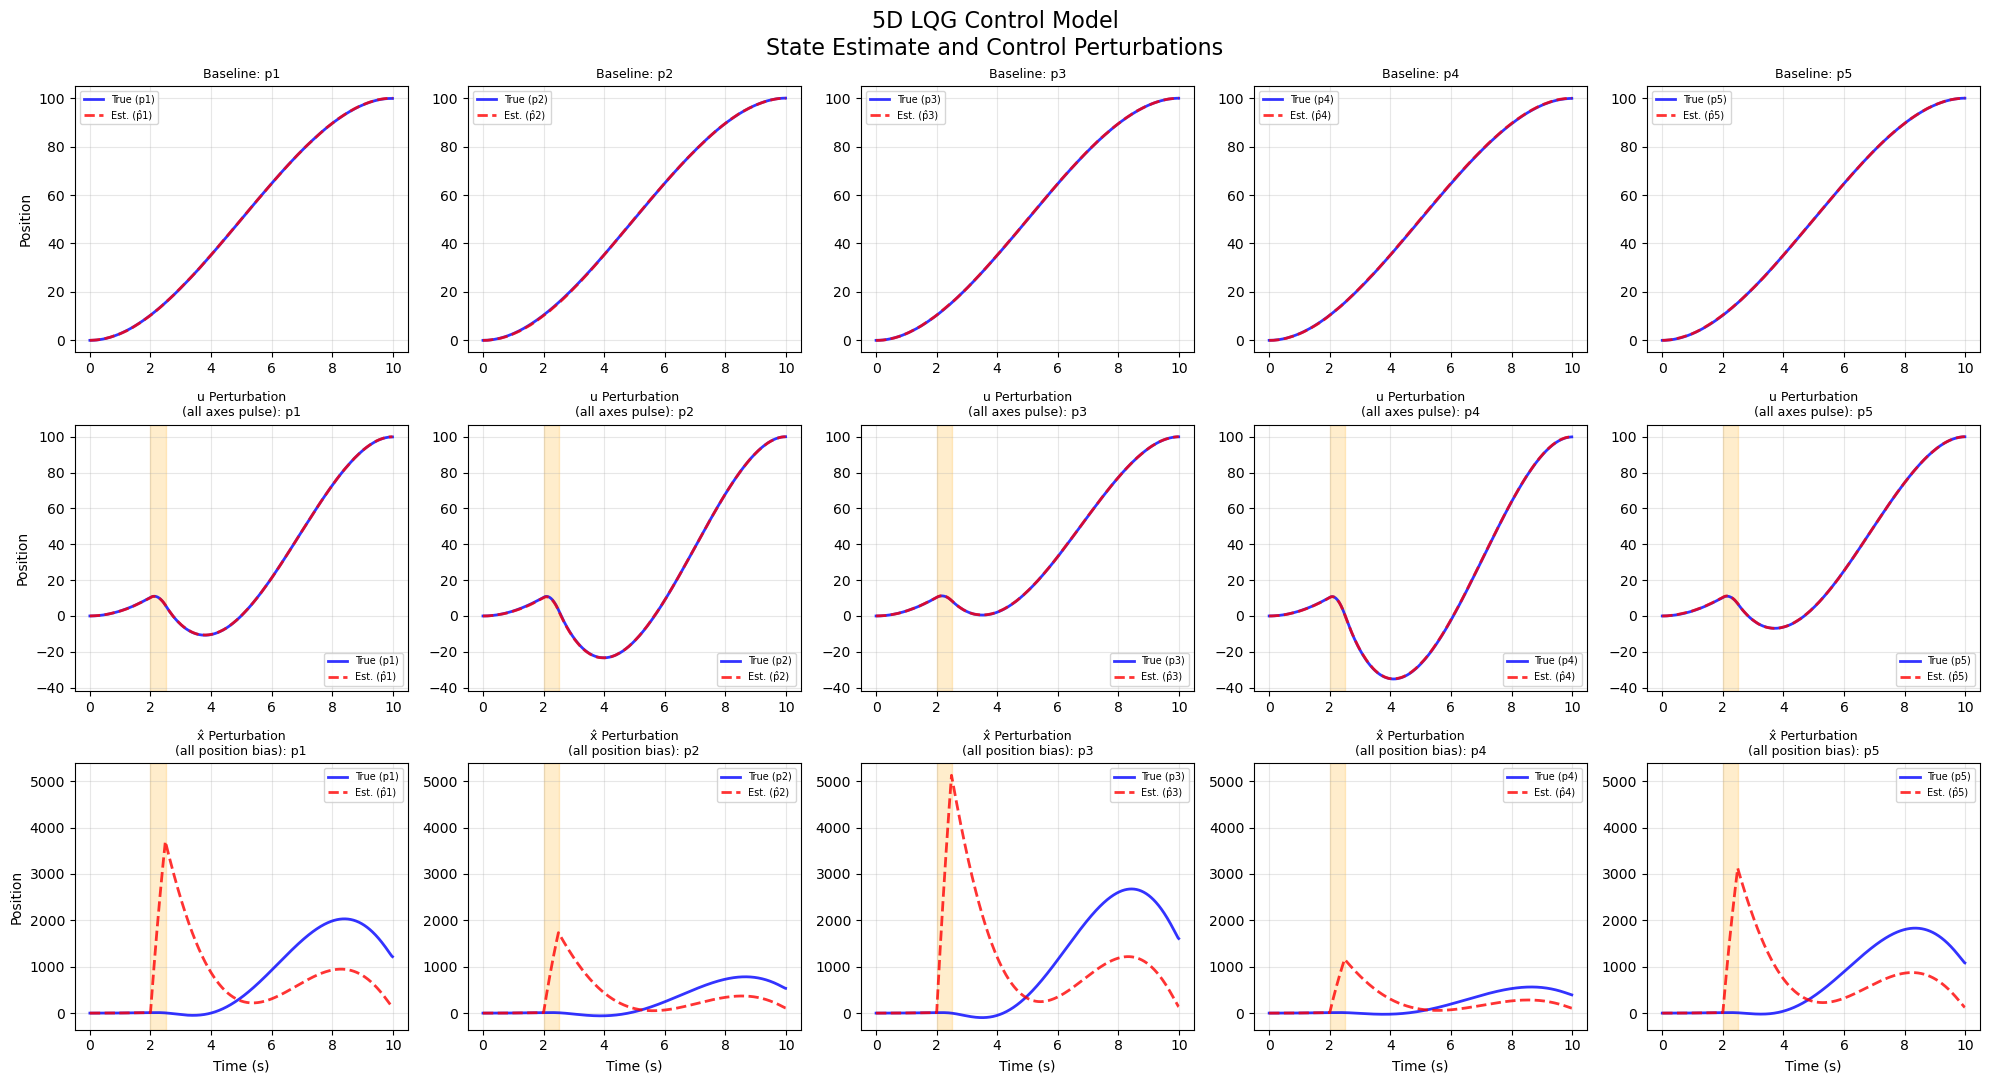

In [7]:
time = np.arange(horizon) * dt
span_kw = dict(alpha=0.2, color='orange')

fig, axes = plt.subplots(3, n_dim, figsize=(4 * n_dim, 11))
fig.suptitle(f'{n_dim}D LQG Control Model\nState Estimate and Control Perturbations', fontsize=16, y=0.98)

row_labels = ['Baseline', 'u Perturbation\n(all axes pulse)', 'x̂ Perturbation\n(all position bias)']
row_data = [
    (pos_baseline,    poshat_baseline,    None),
    (pos_u_pert,      poshat_u_pert,      (perturbation_start, perturbation_end)),
    (pos_xhat_pert,   poshat_xhat_pert,   (perturbation_start, xhat_pulse_end)),
]

for row_idx, (pos, poshat, span) in enumerate(row_data):
    for col_idx in range(n_dim):
        k  = f'p{col_idx + 1}'
        ax = axes[row_idx, col_idx]
        ax.plot(time, pos[k],    'b-',  lw=2, label=f'True ({k})',          alpha=0.8)
        ax.plot(time, poshat[k], 'r--', lw=2, label=f'Est. (p̂{col_idx+1})', alpha=0.8)
        if span:
            ax.axvspan(span[0] * dt, span[1] * dt, **span_kw)
        ax.set_title(f'{row_labels[row_idx]}: {k}', fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel('Position', fontsize=10)
        if row_idx == 2:
            ax.set_xlabel('Time (s)', fontsize=10)

# normalize y-axis per row
for row_idx, (pos, poshat, _) in enumerate(row_data):
    _all = np.concatenate([
        np.concatenate([pos[f'p{i+1}'], poshat[f'p{i+1}']]) for i in range(n_dim)
    ])
    _pad = (_all.max() - _all.min()) * 0.05
    for col_idx in range(n_dim):
        axes[row_idx, col_idx].set_ylim(_all.min() - _pad, _all.max() + _pad)

plt.tight_layout()
plt.show()

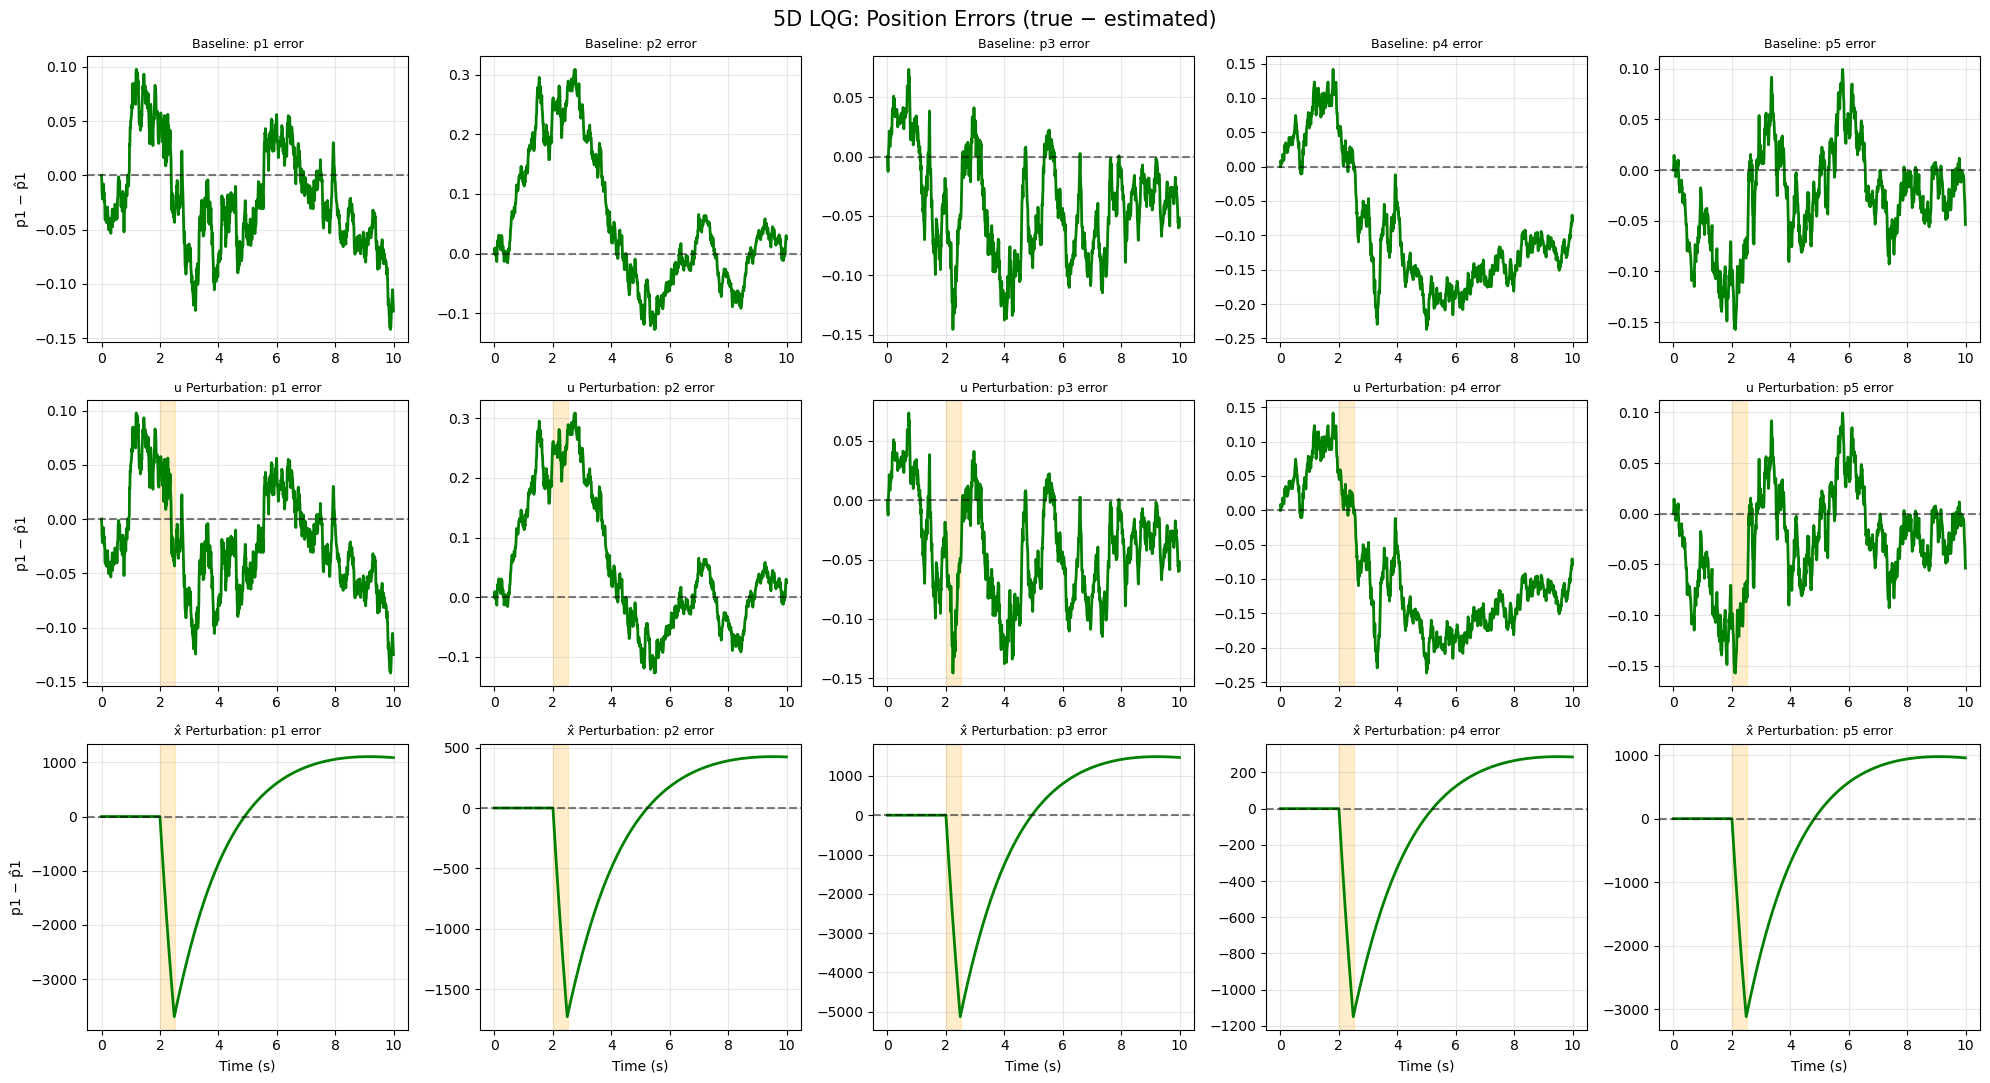

In [8]:
error_baseline = {f'p{i+1}': pos_baseline[f'p{i+1}'] - poshat_baseline[f'p{i+1}'] for i in range(n_dim)}

fig, axes = plt.subplots(3, n_dim, figsize=(4 * n_dim, 11))
fig.suptitle(f'{n_dim}D LQG: Position Errors (true − estimated)', fontsize=15, y=0.98)

errors_row = [
    (error_baseline, None),
    (errors_u,       (perturbation_start, perturbation_end)),
    (errors_xhat,    (perturbation_start, xhat_pulse_end)),
]
row_names = ['Baseline', 'u Perturbation', 'x̂ Perturbation']

for row_idx, (errs, span) in enumerate(errors_row):
    for col_idx in range(n_dim):
        k  = f'p{col_idx + 1}'
        ax = axes[row_idx, col_idx]
        ax.plot(time, errs[k], 'g-', lw=2)
        ax.axhline(0, color='k', ls='--', alpha=0.5)
        if span:
            ax.axvspan(span[0] * dt, span[1] * dt, **span_kw)
        ax.set_title(f'{row_names[row_idx]}: {k} error', fontsize=9)
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel(f'p{col_idx+1} − p̂{col_idx+1}', fontsize=10)
        if row_idx == 2:
            ax.set_xlabel('Time (s)', fontsize=10)

plt.tight_layout()
plt.show()